# SENTRY — ML Model Training

Trains two fraud/spam detection models used by the SENTRY platform:

1. **Fraud Detector** — Random Forest on the Enron email dataset (`data/enron_data_fraud_labeled.csv`)
2. **Spam Classifier** — Random Forest on the SMS Spam Collection (`data/spam.csv`)

**Pipeline design:** TF-IDF vectorizer is fit **only on training data** to prevent data leakage.
Train/test split: 80/20, stratified by label.

**Outputs saved to `models/`:**
- `enron_fraud_rf_model.pkl` + `tfidf_vectorizer.pkl`
- `spam_detector_rf.pkl` + `spam_tfidf_vectorizer.pkl`


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import joblib
import nltk
from pathlib import Path
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, accuracy_score
)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Paths — cross-platform, relative to notebook
DATA_DIR   = Path('data')
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adelu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\adelu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [23]:
# Data loading — Enron email fraud dataset
df = pd.read_csv(DATA_DIR / 'enron_data_fraud_labeled.csv')
print(df.shape)
df.info()

C:\Users\adelu\AppData\Local\Temp\ipykernel_13016\1532594599.py:2: DtypeWarning: Columns (7,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"email Dataset\enron_data_fraud_labeled.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447417 entries, 0 to 447416
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Folder-User                447417 non-null  object 
 1   Folder-Name                447417 non-null  object 
 2   Message-ID                 447417 non-null  object 
 3   Date                       447417 non-null  object 
 4   From                       447417 non-null  object 
 5   To                         447417 non-null  object 
 6   Subject                    429397 non-null  object 
 7   Mime-Version               447417 non-null  object 
 8   Content-Type               447417 non-null  object 
 9   Content-Transfer-Encoding  447417 non-null  object 
 10  X-From                     447417 non-null  object 
 11  X-To                       439238 non-null  object 
 12  X-cc                       109637 non-null  object 
 13  X-bcc                      17

In [24]:
# Preprocessing
df_clean = df[['Body', 'Label']].dropna()

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Lowercase, strip non-alpha, remove stopwords, lemmatize."""
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

# Note: applying to large datasets (447k+ rows) may take 5–10 min
df_clean['Body'] = df_clean['Body'].apply(clean_text)
print(f'Cleaned {len(df_clean):,} rows')

X_train shape: (357933, 5000)
X_test shape: (89484, 5000)


In [25]:
# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    df_clean['Body'], df_clean['Label'],
    test_size=0.2, random_state=42, stratify=df_clean['Label']
)

# TF-IDF: fit ONLY on training data to prevent data leakage
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform train
X_test_tfidf  = tfidf.transform(X_test)         # transform only (no fit)

print(f'Train: {X_train_tfidf.shape}, Test: {X_test_tfidf.shape}')

# Train
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
print('Training...')
rf_model.fit(X_train_tfidf, y_train)
print('Done.')

Starting training... this might take a few minutes given the dataset size.
Training complete!


Accuracy Score: 0.9977
ROC-AUC Score: 0.9799

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     89019
           1       0.99      0.56      0.72       465

    accuracy                           1.00     89484
   macro avg       0.99      0.78      0.86     89484
weighted avg       1.00      1.00      1.00     89484



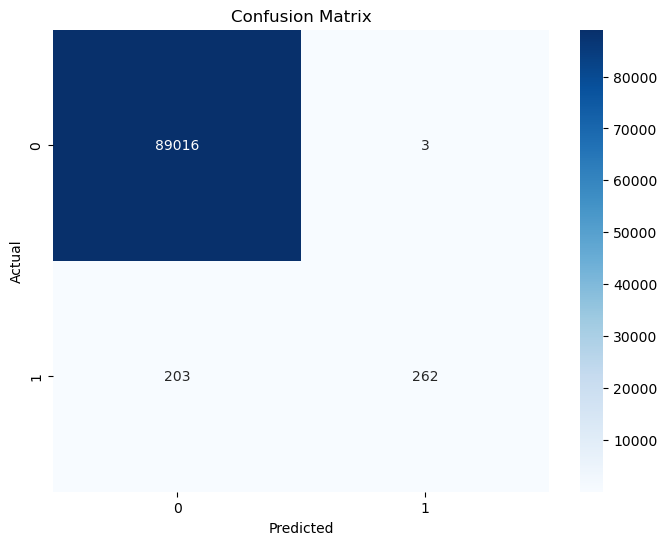

In [26]:
# Evaluation
y_pred = rf_model.predict(X_test_tfidf)
y_prob = rf_model.predict_proba(X_test_tfidf)[:, 1]

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Legit', 'Fraud'],
    yticklabels=['Legit', 'Fraud']
)
plt.title('Confusion Matrix — Enron Fraud Detector')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [27]:
# Save model and vectorizer
joblib.dump(rf_model, MODELS_DIR / 'enron_fraud_rf_model.pkl')
joblib.dump(tfidf,    MODELS_DIR / 'tfidf_vectorizer.pkl')
print('Fraud model saved to models/')

Model and Vectorizer saved successfully!


## Spam Detection Model Training


In [30]:
# All imports already loaded above — skipping duplicates
# Using same clean_text(), stop_words, lemmatizer from Part 1

In [32]:
# Data loading — SMS Spam Collection
df_spam = pd.read_csv(DATA_DIR / 'spam.csv', encoding='latin-1')
df_spam = df_spam[['v1', 'v2']]
df_spam.columns = ['Label', 'Body']
df_spam['Label'] = df_spam['Label'].map({'ham': 0, 'spam': 1})

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

df_spam['Body'] = df_spam['Body'].apply(clean_text)

# Train/test split — stratified
X_tr, X_te, y_tr, y_te = train_test_split(
    df_spam['Body'], df_spam['Label'],
    test_size=0.2, random_state=42, stratify=df_spam['Label']
)

# TF-IDF fit on train only
spam_tfidf = TfidfVectorizer(max_features=5000)
X_tr_tfidf = spam_tfidf.fit_transform(X_tr)
X_te_tfidf = spam_tfidf.transform(X_te)

# Train
spam_rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
spam_rf.fit(X_tr_tfidf, y_tr)

# Evaluate
sp_pred = spam_rf.predict(X_te_tfidf)
sp_prob = spam_rf.predict_proba(X_te_tfidf)[:, 1]
print(f'Accuracy : {accuracy_score(y_te, sp_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_te, sp_prob):.4f}')
print(classification_report(y_te, sp_pred, target_names=['Ham', 'Spam']))

# Save
joblib.dump(spam_rf,    MODELS_DIR / 'spam_detector_rf.pkl')
joblib.dump(spam_tfidf, MODELS_DIR / 'spam_tfidf_vectorizer.pkl')
print('Spam model saved to models/')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adelu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\adelu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Starting training on spam dataset...
Training complete!
Accuracy Score: 0.9758

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       0.99      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115

Model saved as 'spam_detector_rf.pkl'
